# Fraudulent Job Posting Detection: A Comparative Study
**IEEE-Ready Research Notebook**

---

## 1. Environment setup & imports

In [1]:
import pandas as pd
import numpy as np
import re
import html
import time
import math
import warnings
import joblib
import os
from collections import Counter
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, precision_recall_curve, roc_curve)
from scipy.sparse import hstack, csr_matrix
from scipy.stats import wilcoxon
from xgboost import XGBClassifier

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print("All imports successful!")


Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
All imports successful!


## 2. Dataset: EMSCAD benchmark
The Employment Scam Aegean Dataset (EMSCAD) is the standard benchmark for fraudulent job posting detection, originally published by Aegean University. It contains 17,880 real-world job postings.

In [2]:
# Load EMSCAD benchmark dataset
df = pd.read_csv("fake_job_postings.csv")

print(f"Dataset: EMSCAD (Employment Scam Aegean Dataset)")
print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df['fraudulent'].value_counts())
print(f"\nFraud rate: {df['fraudulent'].mean()*100:.2f}% (highly imbalanced)")
print(f"\nImbalance ratio: 1:{int((1-df['fraudulent'].mean())/df['fraudulent'].mean())}")
print(f"\nMissing values (top columns):")
for col in df.columns:
    m = df[col].isna().sum()
    if m > 0:
        print(f"  {col:25s} {m:,} ({m/len(df)*100:.1f}%)")


Dataset: EMSCAD (Employment Scam Aegean Dataset)
Shape: (17880, 18)

Class distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64

Fraud rate: 4.84% (highly imbalanced)

Imbalance ratio: 1:19

Missing values (top columns):
  location                  346 (1.9%)
  department                11,547 (64.6%)
  salary_range              15,012 (84.0%)
  company_profile           3,308 (18.5%)
  description               1 (0.0%)
  requirements              2,696 (15.1%)
  benefits                  7,212 (40.3%)
  employment_type           3,471 (19.4%)
  required_experience       7,050 (39.4%)
  required_education        8,105 (45.3%)
  industry                  4,903 (27.4%)
  function                  6,455 (36.1%)


## 3. Exploratory data analysis

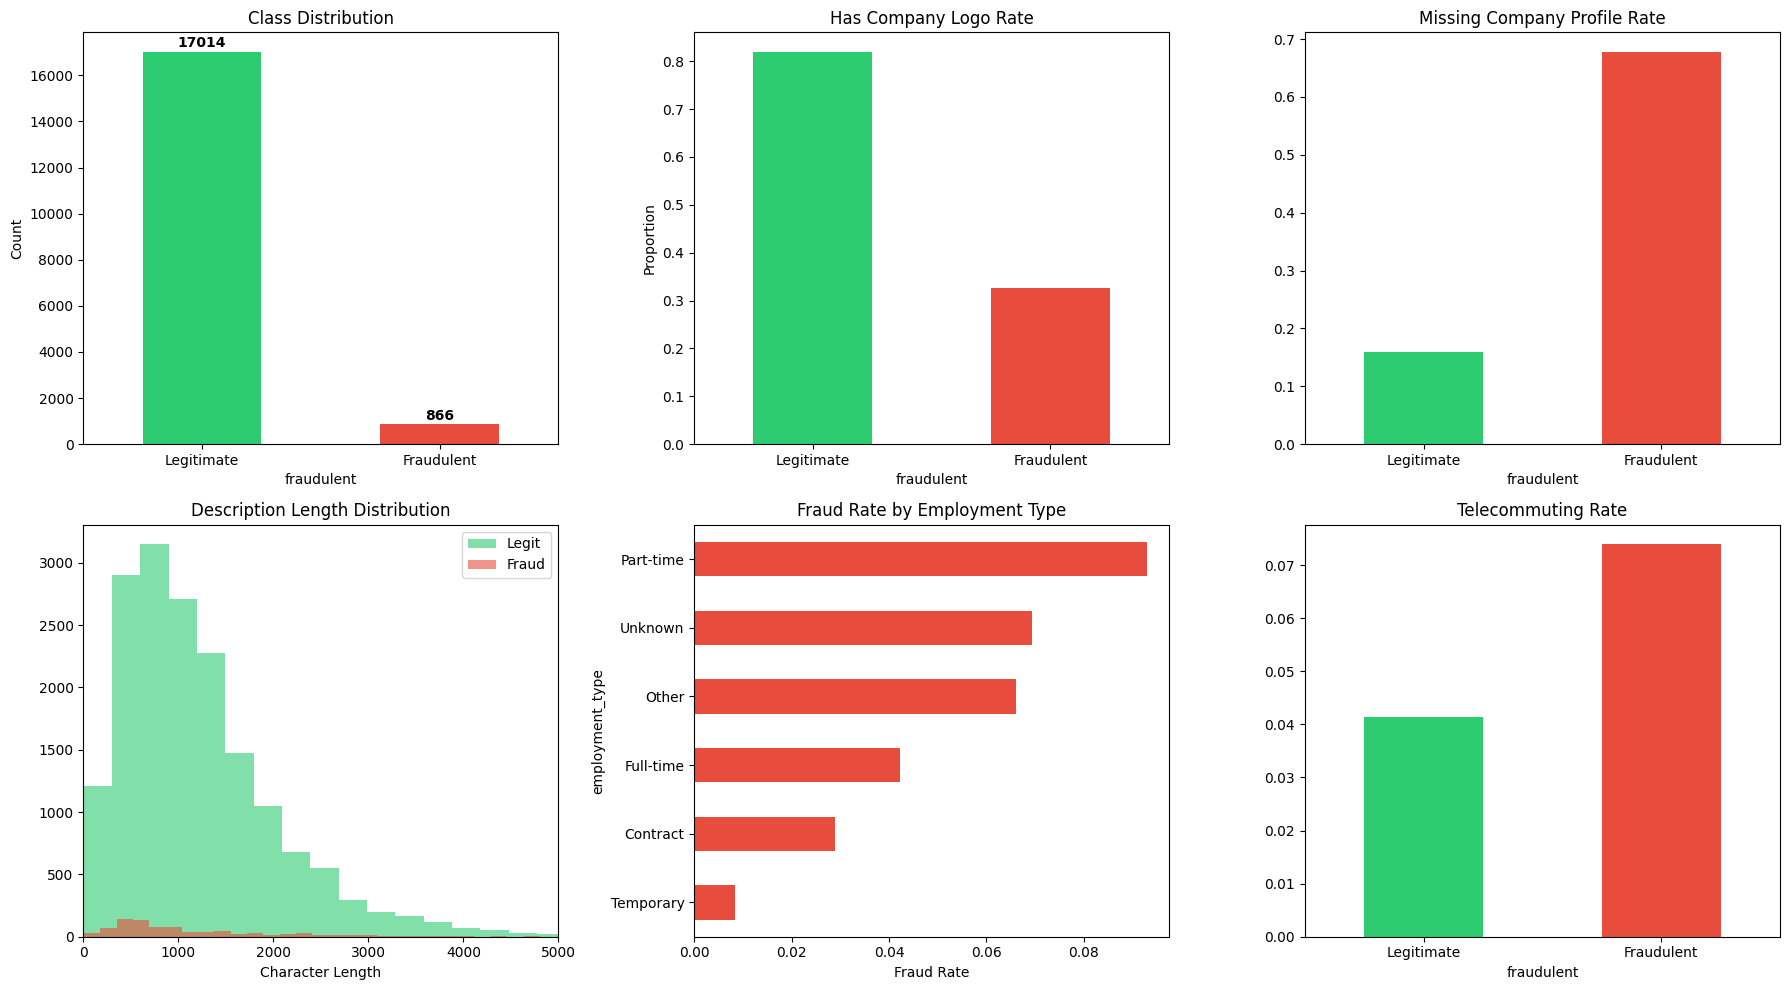

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Class distribution
ax = axes[0, 0]
df['fraudulent'].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Class Distribution')
ax.set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)
ax.set_ylabel('Count')
for i, v in enumerate(df['fraudulent'].value_counts()):
    ax.text(i, v + 200, str(v), ha='center', fontweight='bold')

# Company logo presence
ax = axes[0, 1]
logo_data = df.groupby('fraudulent')['has_company_logo'].mean()
logo_data.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Has Company Logo Rate')
ax.set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)
ax.set_ylabel('Proportion')

# Missing company profile
ax = axes[0, 2]
missing_cp = df.groupby('fraudulent')['company_profile'].apply(lambda x: x.isna().mean())
missing_cp.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Missing Company Profile Rate')
ax.set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)

# Text length distribution
ax = axes[1, 0]
for label, color, name in [(0, '#2ecc71', 'Legit'), (1, '#e74c3c', 'Fraud')]:
    lengths = df[df['fraudulent']==label]['description'].dropna().str.len()
    ax.hist(lengths, bins=50, alpha=0.6, color=color, label=name)
ax.set_title('Description Length Distribution')
ax.set_xlabel('Character Length')
ax.legend()
ax.set_xlim(0, 5000)

# Employment type
ax = axes[1, 1]
emp_fraud = pd.crosstab(df['employment_type'].fillna('Unknown'), df['fraudulent'], normalize='index')
if 1 in emp_fraud.columns:
    emp_fraud[1].sort_values().plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_title('Fraud Rate by Employment Type')
ax.set_xlabel('Fraud Rate')

# Telecommuting
ax = axes[1, 2]
tc_data = df.groupby('fraudulent')['telecommuting'].mean()
tc_data.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Telecommuting Rate')
ax.set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Text preprocessing & feature engineering

In [4]:
TEXT_COLS = ['title', 'company_profile', 'description', 'requirements', 'benefits']
CAT_COLS = ['employment_type', 'required_experience', 'required_education', 'industry', 'function']
NUM_COLS = ['telecommuting', 'has_company_logo', 'has_questions']

def clean_text(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'#URL_\w+#', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^\w\s.,!?;:\'\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

for col in TEXT_COLS:
    df[col] = df[col].fillna("").apply(clean_text)

df['combined_text'] = df[TEXT_COLS].apply(lambda row: ' '.join(row), axis=1)

# Engineered features
df['text_length'] = df['combined_text'].str.len()
df['word_count'] = df['combined_text'].str.split().str.len()
df['avg_word_length'] = df['combined_text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.strip() else 0
)
df['has_salary_mention'] = df['combined_text'].str.contains(
    r'\$|salary|pay|compensation|wage', case=False, regex=True
).astype(int)
df['has_email'] = df['combined_text'].str.contains(r'@\w+\.\w+', regex=True).astype(int)
df['exclamation_count'] = df['combined_text'].str.count('!')
df['upper_ratio'] = df[TEXT_COLS].apply(lambda row: ' '.join(row), axis=1).apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)
df['missing_profile'] = df['company_profile'].apply(lambda x: 1 if x == "" else 0)
df['missing_benefits'] = df['benefits'].apply(lambda x: 1 if x == "" else 0)
df['missing_requirements'] = df['requirements'].apply(lambda x: 1 if x == "" else 0)

# Fraud signal features
def extract_fraud_signals(text):
    t = text.lower()
    return {
        'has_fee': int(bool(re.search(r'fee|registration cost|processing fee|verification fee', t))),
        'has_pay_to_work': int(bool(re.search(r'pay.*to (start|begin|access|join)|payment.*required', t))),
        'has_gmail_contact': int(bool(re.search(r'@gmail\.com|@yahoo\.com|@hotmail\.com', t))),
        'has_messaging_app': int(bool(re.search(r'whatsapp|telegram|wechat', t))),
        'has_unrealistic_pay': int(bool(re.search(r'earn.*\$\d{4,}.*per\s*(week|day)', t))),
        'has_easy_money': int(bool(re.search(r'be your own boss|financial freedom|unlimited income', t))),
        'has_no_experience': int(bool(re.search(r'no experience|no skills|anyone can', t))),
        'has_urgent': int(bool(re.search(r'start (today|now|immediately)|urgent hiring', t))),
        'has_crypto': int(bool(re.search(r'crypto|bitcoin|blockchain|web3|nft', t))),
    }

fraud_signals = df['combined_text'].apply(extract_fraud_signals)
fraud_signal_df = pd.DataFrame(fraud_signals.tolist())
for col in fraud_signal_df.columns:
    df[col] = fraud_signal_df[col]

FRAUD_SIGNAL_COLS = list(fraud_signal_df.columns)

for col in CAT_COLS:
    df[col] = df[col].fillna("Unknown")

df = df[df['combined_text'].str.len() > 10].reset_index(drop=True)

ENGINEERED_COLS = ['text_length', 'word_count', 'avg_word_length', 'has_salary_mention',
                   'has_email', 'exclamation_count', 'upper_ratio',
                   'missing_profile', 'missing_benefits', 'missing_requirements']

ALL_NUM_COLS = NUM_COLS + ENGINEERED_COLS + FRAUD_SIGNAL_COLS

print(f"After preprocessing: {len(df):,} rows")
print(f"Text features: TF-IDF (fitted per fold)")
print(f"Numerical features: {len(ALL_NUM_COLS)}")
print(f"Categorical features: {len(CAT_COLS)}")
print(f"Fraud signal features: {len(FRAUD_SIGNAL_COLS)}")


After preprocessing: 17,880 rows
Text features: TF-IDF (fitted per fold)
Numerical features: 22
Categorical features: 5
Fraud signal features: 9


## 5. Stratified 5-fold cross-validation framework
To ensure robust evaluation, we use stratified 5-fold cross-validation. All feature engineering (TF-IDF fitting, scaling) is performed within each fold to prevent data leakage.

In [5]:
def build_features(train_df, test_df):
    """Build feature matrices within a single fold (no data leakage)."""
    # TF-IDF
    tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 3), min_df=2,
                             max_df=0.95, sublinear_tf=True, strip_accents='unicode')
    X_train_tfidf = tfidf.fit_transform(train_df['combined_text'])
    X_test_tfidf = tfidf.transform(test_df['combined_text'])

    # Categorical
    train_cat, test_cat = [], []
    for col in CAT_COLS:
        le = LabelEncoder()
        train_cat.append(le.fit_transform(train_df[col].astype(str)).reshape(-1, 1))
        test_cat.append(le.transform(test_df[col].astype(str).apply(
            lambda x: x if x in le.classes_ else le.classes_[0])).reshape(-1, 1))

    # Numerical
    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(train_df[ALL_NUM_COLS].fillna(0))
    X_test_num = scaler.transform(test_df[ALL_NUM_COLS].fillna(0))

    # Combine
    X_train = hstack([X_train_tfidf, csr_matrix(X_train_num), csr_matrix(np.hstack(train_cat))])
    X_test = hstack([X_test_tfidf, csr_matrix(X_test_num), csr_matrix(np.hstack(test_cat))])

    return X_train, X_test, tfidf, scaler

def get_sklearn_models():
    """Return fresh model instances for each fold."""
    return {
        'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs', n_jobs=-1),
        'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=30, class_weight='balanced', n_jobs=-1, random_state=42),
        'XGBoost': XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, scale_pos_weight=10,
                                  eval_metric='logloss', n_jobs=-1, random_state=42, use_label_encoder=False),
        'SVM': CalibratedClassifierCV(LinearSVC(C=1.0, class_weight='balanced', max_iter=5000, random_state=42), cv=3),
    }

print("Cross-validation framework ready.")


Cross-validation framework ready.


## 6. Sklearn models — 5-fold cross-validation

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y = df['fraudulent'].values

# Store results per model per fold
cv_results = {name: {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
              for name in get_sklearn_models().keys()}

# Store predictions for statistical tests
all_predictions = {name: np.zeros(len(df)) for name in get_sklearn_models().keys()}

for fold, (train_idx, test_idx) in enumerate(skf.split(df, y)):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold+1}/5")
    print(f"{'='*60}")

    train_df_fold = df.iloc[train_idx].reset_index(drop=True)
    test_df_fold = df.iloc[test_idx].reset_index(drop=True)
    y_train_fold = y[train_idx]
    y_test_fold = y[test_idx]

    # Build features within fold
    X_train, X_test, _, _ = build_features(train_df_fold, test_df_fold)

    # Train and evaluate each model
    models = get_sklearn_models()
    for name, model in models.items():
        start = time.time()
        model.fit(X_train, y_train_fold)
        elapsed = time.time() - start

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        cv_results[name]['accuracy'].append(accuracy_score(y_test_fold, y_pred))
        cv_results[name]['precision'].append(precision_score(y_test_fold, y_pred, zero_division=0))
        cv_results[name]['recall'].append(recall_score(y_test_fold, y_pred, zero_division=0))
        cv_results[name]['f1'].append(f1_score(y_test_fold, y_pred, zero_division=0))
        cv_results[name]['roc_auc'].append(roc_auc_score(y_test_fold, y_proba) if y_proba is not None else 0)

        all_predictions[name][test_idx] = y_pred
        print(f"  {name:25s} F1={cv_results[name]['f1'][-1]:.4f} | AUC={cv_results[name]['roc_auc'][-1]:.4f} | {elapsed:.1f}s")

# Summary table
print(f"\n\n{'='*80}")
print("  5-FOLD CROSS-VALIDATION RESULTS (mean +/- std)")
print(f"{'='*80}")
summary_rows = []
for name in cv_results:
    row = {'Model': name}
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        vals = cv_results[name][metric]
        row[f'{metric}_mean'] = np.mean(vals)
        row[f'{metric}_std'] = np.std(vals)
        row[f'{metric}_display'] = f"{np.mean(vals):.4f} +/- {np.std(vals):.4f}"
    summary_rows.append(row)
    print(f"  {name:25s} F1={row['f1_display']:20s} AUC={row['roc_auc_display']}")

summary_df = pd.DataFrame(summary_rows).sort_values('f1_mean', ascending=False)



  FOLD 1/5
  Logistic Regression       F1=0.7352 | AUC=0.9927 | 43.7s
  Random Forest             F1=0.7416 | AUC=0.9831 | 4.9s
  XGBoost                   F1=0.8715 | AUC=0.9889 | 302.5s
  SVM                       F1=0.8812 | AUC=0.9919 | 197.4s

  FOLD 2/5
  Logistic Regression       F1=0.6837 | AUC=0.9908 | 42.1s
  Random Forest             F1=0.7394 | AUC=0.9813 | 4.8s
  XGBoost                   F1=0.8502 | AUC=0.9873 | 298.3s
  SVM                       F1=0.8788 | AUC=0.9919 | 191.4s

  FOLD 3/5
  Logistic Regression       F1=0.7294 | AUC=0.9909 | 42.8s
  Random Forest             F1=0.7645 | AUC=0.9817 | 5.1s
  XGBoost                   F1=0.8509 | AUC=0.9907 | 296.0s
  SVM                       F1=0.8133 | AUC=0.9919 | 182.9s

  FOLD 4/5
  Logistic Regression       F1=0.7207 | AUC=0.9924 | 39.2s
  Random Forest             F1=0.7740 | AUC=0.9859 | 4.8s
  XGBoost                   F1=0.8754 | AUC=0.9936 | 294.7s
  SVM                       F1=0.8726 | AUC=0.9933 | 201.7s

  F

## 7. Deep learning models — 5-fold cross-validation
BiLSTM and Transformer models trained on GPU with the same 5-fold splits.

In [7]:
class SimpleTokenizer:
    def __init__(self, vocab_size=30000):
        self.vocab_size = vocab_size
        self.word2idx = {'<PAD>': 0, '<OOV>': 1}

    def fit(self, texts):
        word_counts = Counter()
        for text in texts:
            word_counts.update(text.split())
        for i, (word, _) in enumerate(word_counts.most_common(self.vocab_size - 2)):
            self.word2idx[word] = i + 2

    def encode(self, texts, max_len=256):
        seqs = []
        for text in texts:
            seq = [self.word2idx.get(w, 1) for w in text.split()[:max_len]]
            seq += [0] * (max_len - len(seq))
            seqs.append(seq)
        return np.array(seqs)

class TextDataset(Dataset):
    def __init__(self, sequences, labels):
        self.X = torch.LongTensor(sequences)
        self.y = torch.FloatTensor(labels)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size=30000, embed_dim=128, lstm_units=64, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, lstm_units, batch_first=True, bidirectional=True, num_layers=2, dropout=0.2)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_units * 2, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1))

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        x = out.max(dim=1)[0]
        return self.classifier(x).squeeze(-1)

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size=30000, embed_dim=128, num_heads=4, num_layers=2, dropout=0.3, max_len=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        pe = torch.zeros(max_len, embed_dim)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
        self.dropout = nn.Dropout(dropout)
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads,
                dim_feedforward=256, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.classifier = nn.Sequential(nn.Linear(embed_dim, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        mask = (x == 0)
        x = self.embedding(x) + self.pe[:, :x.size(1), :]
        x = self.dropout(x)
        x = self.encoder(x, src_key_padding_mask=mask)
        m = (~mask).unsqueeze(-1).float()
        x = (x * m).sum(1) / m.sum(1).clamp(min=1)
        return self.classifier(x).squeeze(-1)

def train_dl_model(model, train_loader, val_loader, y_train, epochs=10, lr=0.001):
    n_pos = (y_train == 1).sum()
    n_neg = (y_train == 0).sum()
    pw = torch.tensor([n_neg / max(n_pos, 1)], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    best_loss, best_state, patience = float('inf'), None, 0

    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        vl = sum(criterion(model(bx.to(device)), by.to(device)).item()
                 for bx, by in val_loader) / len(val_loader)
        if vl < best_loss:
            best_loss = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= 3: break

    if best_state:
        model.load_state_dict(best_state)
        model.to(device)
    return model

def predict_dl(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for bx, _ in loader:
            probs.append(torch.sigmoid(model(bx.to(device))).cpu().numpy())
    return np.concatenate(probs)

print("Deep learning models defined.")


Deep learning models defined.


## 8. Run deep learning 5-fold CV

In [8]:
MAX_LEN = 256
BATCH_SIZE = 128
VOCAB_SIZE = 30000

dl_models_config = {
    'BiLSTM': {'cls': LSTMClassifier, 'lr': 0.001, 'epochs': 10},
    'Transformer': {'cls': TransformerClassifier, 'lr': 0.0005, 'epochs': 8},
}

for name in dl_models_config:
    cv_results[name] = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
    all_predictions[name] = np.zeros(len(df))

for fold, (train_idx, test_idx) in enumerate(skf.split(df, y)):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold+1}/5 (Deep Learning)")
    print(f"{'='*60}")

    train_texts = df.iloc[train_idx]['combined_text'].values
    test_texts = df.iloc[test_idx]['combined_text'].values
    y_train_fold = y[train_idx]
    y_test_fold = y[test_idx]

    # Tokenize within fold
    tok = SimpleTokenizer(VOCAB_SIZE)
    tok.fit(train_texts)
    X_train_seq = tok.encode(train_texts, MAX_LEN)
    X_test_seq = tok.encode(test_texts, MAX_LEN)

    # Split train into train/val for early stopping
    tr_idx, val_idx = train_test_split(range(len(X_train_seq)), test_size=0.1,
                                        random_state=42, stratify=y_train_fold)
    train_loader = DataLoader(TextDataset(X_train_seq[tr_idx], y_train_fold[tr_idx]),
                               batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TextDataset(X_train_seq[val_idx], y_train_fold[val_idx]),
                             batch_size=BATCH_SIZE)
    test_loader = DataLoader(TextDataset(X_test_seq, y_test_fold), batch_size=BATCH_SIZE)

    for name, cfg in dl_models_config.items():
        start = time.time()
        model = cfg['cls'](vocab_size=VOCAB_SIZE, max_len=MAX_LEN).to(device) if name == 'Transformer' else cfg['cls'](vocab_size=VOCAB_SIZE).to(device)
        model = train_dl_model(model, train_loader, val_loader, y_train_fold, epochs=cfg['epochs'], lr=cfg['lr'])

        y_proba = predict_dl(model, test_loader)
        y_pred = (y_proba >= 0.5).astype(int)
        elapsed = time.time() - start

        cv_results[name]['accuracy'].append(accuracy_score(y_test_fold, y_pred))
        cv_results[name]['precision'].append(precision_score(y_test_fold, y_pred, zero_division=0))
        cv_results[name]['recall'].append(recall_score(y_test_fold, y_pred, zero_division=0))
        cv_results[name]['f1'].append(f1_score(y_test_fold, y_pred, zero_division=0))
        cv_results[name]['roc_auc'].append(roc_auc_score(y_test_fold, y_proba))
        all_predictions[name][test_idx] = y_pred

        print(f"  {name:25s} F1={cv_results[name]['f1'][-1]:.4f} | AUC={cv_results[name]['roc_auc'][-1]:.4f} | {elapsed:.1f}s")

        del model
        torch.cuda.empty_cache()



  FOLD 1/5 (Deep Learning)
  BiLSTM                    F1=0.7433 | AUC=0.9804 | 17.4s
  Transformer               F1=0.5927 | AUC=0.9819 | 52.2s

  FOLD 2/5 (Deep Learning)
  BiLSTM                    F1=0.6393 | AUC=0.9716 | 13.3s
  Transformer               F1=0.4894 | AUC=0.9716 | 45.6s

  FOLD 3/5 (Deep Learning)
  BiLSTM                    F1=0.6154 | AUC=0.9764 | 9.5s
  Transformer               F1=0.6484 | AUC=0.9810 | 52.1s

  FOLD 4/5 (Deep Learning)
  BiLSTM                    F1=0.4709 | AUC=0.9744 | 9.4s
  Transformer               F1=0.5880 | AUC=0.9744 | 52.1s

  FOLD 5/5 (Deep Learning)
  BiLSTM                    F1=0.5277 | AUC=0.9665 | 9.7s
  Transformer               F1=0.5898 | AUC=0.9698 | 45.7s


In [9]:
## BERT Fine-tuning - 5-fold CV
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.encodings = tokenizer(list(texts), truncation=True, padding='max_length',
                                    max_length=max_len, return_tensors='pt')
        self.labels = torch.FloatTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

def train_bert(train_texts, train_labels, val_texts, val_labels, epochs=3, lr=2e-5, batch_size=16):
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=1,
                                                           problem_type="multi_label_classification")
    model.to(device)
    
    train_dataset = BertDataset(train_texts, train_labels, bert_tokenizer, max_len=256)
    val_dataset = BertDataset(val_texts, val_labels, bert_tokenizer, max_len=256)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    # Class weight
    n_pos = train_labels.sum()
    n_neg = len(train_labels) - n_pos
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    
    best_val_loss = float('inf')
    best_state = None
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits.squeeze(-1), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                val_loss += criterion(outputs.logits.squeeze(-1), labels).item()
        
        val_loss /= len(val_loader)
        avg_loss = total_loss / len(train_loader)
        print(f"    Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Val Loss: {val_loss:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    
    if best_state:
        model.load_state_dict(best_state)
        model.to(device)
    return model

def predict_bert(model, texts, batch_size=32):
    dataset = BertDataset(texts, np.zeros(len(texts)), bert_tokenizer, max_len=256)
    loader = DataLoader(dataset, batch_size=batch_size)
    
    model.eval()
    all_proba = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            proba = torch.sigmoid(outputs.logits.squeeze(-1))
            all_proba.append(proba.cpu().numpy())
    return np.concatenate(all_proba)

# Run BERT 5-fold CV
cv_results['BERT'] = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
all_predictions['BERT'] = np.zeros(len(df))

for fold, (train_idx, test_idx) in enumerate(skf.split(df, y)):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold+1}/5 (BERT)")
    print(f"{'='*60}")
    
    train_texts = df.iloc[train_idx]['combined_text'].values
    test_texts = df.iloc[test_idx]['combined_text'].values
    y_train_fold = y[train_idx]
    y_test_fold = y[test_idx]
    
    # Split train into train/val
    tr_idx, val_idx = train_test_split(range(len(train_texts)), test_size=0.1,
                                        random_state=42, stratify=y_train_fold)
    
    start = time.time()
    bert_model = train_bert(
        train_texts[tr_idx], y_train_fold[tr_idx],
        train_texts[val_idx], y_train_fold[val_idx],
        epochs=3, lr=2e-5, batch_size=16
    )
    
    y_proba = predict_bert(bert_model, test_texts, batch_size=32)
    y_pred = (y_proba >= 0.5).astype(int)
    elapsed = time.time() - start
    
    cv_results['BERT']['accuracy'].append(accuracy_score(y_test_fold, y_pred))
    cv_results['BERT']['precision'].append(precision_score(y_test_fold, y_pred, zero_division=0))
    cv_results['BERT']['recall'].append(recall_score(y_test_fold, y_pred, zero_division=0))
    cv_results['BERT']['f1'].append(f1_score(y_test_fold, y_pred, zero_division=0))
    cv_results['BERT']['roc_auc'].append(roc_auc_score(y_test_fold, y_proba))
    all_predictions['BERT'][test_idx] = y_pred
    
    print(f"  BERT: F1={cv_results['BERT']['f1'][-1]:.4f} | AUC={cv_results['BERT']['roc_auc'][-1]:.4f} | {elapsed:.1f}s")
    
    # Free GPU memory
    del bert_model
    torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"  BERT 5-FOLD CV RESULTS")
print(f"{'='*60}")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    vals = cv_results['BERT'][metric]
    print(f"  {metric:15s} {np.mean(vals):.4f} +/- {np.std(vals):.4f}")


  FOLD 1/5 (BERT)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2504.88it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

    Epoch 1/3 - Loss: 1.3242 - Val Loss: 1.0583
    Epoch 2/3 - Loss: 0.6933 - Val Loss: 1.2471
    Epoch 3/3 - Loss: 0.3589 - Val Loss: 1.9220
  BERT: F1=0.8036 | AUC=0.9546 | 1457.9s

  FOLD 2/5 (BERT)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3651.48it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

    Epoch 1/3 - Loss: 1.3450 - Val Loss: 1.0632
    Epoch 2/3 - Loss: 0.7586 - Val Loss: 1.0731
    Epoch 3/3 - Loss: 0.2978 - Val Loss: 1.2621
  BERT: F1=0.8228 | AUC=0.9822 | 1460.5s

  FOLD 3/5 (BERT)


...

    Epoch 1/3 - Loss: 1.3840 - Val Loss: 1.6438
    Epoch 2/3 - Loss: 0.7610 - Val Loss: 0.6904
    Epoch 3/3 - Loss: 0.3313 - Val Loss: 1.6153
  BERT: F1=0.7527 | AUC=0.9763 | 1457.3s

  FOLD 4/5 (BERT)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3846.78it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

    Epoch 1/3 - Loss: 1.4342 - Val Loss: 1.2762
    Epoch 2/3 - Loss: 0.8517 - Val Loss: 1.1459
    Epoch 3/3 - Loss: 0.3254 - Val Loss: 1.0964
  BERT: F1=0.8680 | AUC=0.9889 | 1455.3s

  FOLD 5/5 (BERT)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4372.32it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

    Epoch 1/3 - Loss: 1.3602 - Val Loss: 1.0327
    Epoch 2/3 - Loss: 0.7016 - Val Loss: 1.2999
    Epoch 3/3 - Loss: 0.3502 - Val Loss: 1.3589
  BERT: F1=0.7118 | AUC=0.9673 | 1460.0s

  BERT 5-FOLD CV RESULTS
  accuracy        0.9799 +/- 0.0056
  precision       0.7996 +/- 0.0705
  recall          0.7865 +/- 0.0522
  f1              0.7918 +/- 0.0545
  roc_auc         0.9739 +/- 0.0120


## 9. Complete model comparison with confidence intervals

In [10]:
# Build full comparison table
all_summary = []
for name in cv_results:
    row = {'Model': name}
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        vals = cv_results[name][metric]
        row[f'{metric}_mean'] = np.mean(vals)
        row[f'{metric}_std'] = np.std(vals)
    all_summary.append(row)

results_df = pd.DataFrame(all_summary).sort_values('f1_mean', ascending=False).reset_index(drop=True)

print("=" * 90)
print("  COMPLETE 5-FOLD CV RESULTS (mean +/- std)")
print("=" * 90)
print(f"{'Model':25s} {'Accuracy':18s} {'Precision':18s} {'Recall':18s} {'F1':18s} {'ROC-AUC':18s}")
print("-" * 90)
for _, row in results_df.iterrows():
    print(f"{row['Model']:25s}", end=" ")
    for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        print(f"{row[f'{m}_mean']:.4f}+/-{row[f'{m}_std']:.4f}", end="  ")
    print()

print(f"\nBest model by F1: {results_df.iloc[0]['Model']} ({results_df.iloc[0]['f1_mean']:.4f})")


  COMPLETE 5-FOLD CV RESULTS (mean +/- std)
Model                     Accuracy           Precision          Recall             F1                 ROC-AUC           
------------------------------------------------------------------------------------------
SVM                       0.9869+/-0.0026  0.9494+/-0.0184  0.7714+/-0.0554  0.8500+/-0.0340  0.9909+/-0.0026  
XGBoost                   0.9864+/-0.0025  0.9226+/-0.0163  0.7842+/-0.0491  0.8470+/-0.0318  0.9895+/-0.0024  
BERT                      0.9799+/-0.0056  0.7996+/-0.0705  0.7865+/-0.0522  0.7918+/-0.0545  0.9739+/-0.0120  
Random Forest             0.9761+/-0.0032  0.7901+/-0.0299  0.6895+/-0.0494  0.7360+/-0.0401  0.9814+/-0.0035  
Logistic Regression       0.9637+/-0.0040  0.5812+/-0.0297  0.9111+/-0.0228  0.7092+/-0.0241  0.9908+/-0.0019  
BiLSTM                    0.9394+/-0.0250  0.4682+/-0.1143  0.8718+/-0.0371  0.5993+/-0.0940  0.9739+/-0.0047  
Transformer               0.9358+/-0.0160  0.4331+/-0.0575  0.8996+/-0.0

## 10. Statistical significance tests
McNemar's test compares whether two models make significantly different errors. We compare the best model against all others.

In [11]:
from statsmodels.stats.contingency_tables import mcnemar

best_model_name = results_df.iloc[0]['Model']
best_preds = all_predictions[best_model_name]

print(f"Statistical significance tests (McNemar's test)")
print(f"Reference model: {best_model_name}")
print(f"{'='*60}")
print(f"{'Comparison':40s} {'p-value':12s} {'Significant?'}")
print(f"{'-'*60}")

for name in all_predictions:
    if name == best_model_name:
        continue
    other_preds = all_predictions[name]

    # Build contingency table
    b = np.sum((best_preds == y) & (other_preds != y))  # best correct, other wrong
    c = np.sum((best_preds != y) & (other_preds == y))  # best wrong, other correct

    table = np.array([[0, b], [c, 0]])
    if b + c > 0:
        result = mcnemar(table, exact=True)
        sig = "Yes (p<0.05)" if result.pvalue < 0.05 else "No"
        print(f"  {best_model_name} vs {name:25s} p={result.pvalue:.6f}  {sig}")
    else:
        print(f"  {best_model_name} vs {name:25s} identical predictions")


Statistical significance tests (McNemar's test)
Reference model: SVM
Comparison                               p-value      Significant?
------------------------------------------------------------
  SVM vs Logistic Regression       p=0.000000  Yes (p<0.05)
  SVM vs Random Forest             p=0.000000  Yes (p<0.05)
  SVM vs XGBoost                   p=0.482306  No
  SVM vs BiLSTM                    p=0.000000  Yes (p<0.05)
  SVM vs Transformer               p=0.000000  Yes (p<0.05)
  SVM vs BERT                      p=0.000000  Yes (p<0.05)


## 11. Ablation study
We measure the contribution of each feature group by training the best model with features removed one group at a time.

In [12]:
# Use a single 80/20 split for ablation (faster)
train_df_abl, test_df_abl = train_test_split(df, test_size=0.2, random_state=42, stratify=df['fraudulent'])
y_train_abl = train_df_abl['fraudulent'].values
y_test_abl = test_df_abl['fraudulent'].values

# Full model baseline
X_train_full, X_test_full, _, _ = build_features(train_df_abl, test_df_abl)
lr_full = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs', n_jobs=-1)
lr_full.fit(X_train_full, y_train_abl)
f1_full = f1_score(y_test_abl, lr_full.predict(X_test_full))
auc_full = roc_auc_score(y_test_abl, lr_full.predict_proba(X_test_full)[:, 1])

print(f"Full model baseline: F1={f1_full:.4f}, AUC={auc_full:.4f}")
print(f"\n{'Feature Group Removed':35s} {'F1':10s} {'AUC':10s} {'F1 Drop':10s}")
print("-" * 65)

# Ablation: TF-IDF only (no engineered/fraud/categorical features)
tfidf_abl = TfidfVectorizer(max_features=50000, ngram_range=(1, 3), min_df=2, max_df=0.95, sublinear_tf=True)
X_tr_tfidf = tfidf_abl.fit_transform(train_df_abl['combined_text'])
X_te_tfidf = tfidf_abl.transform(test_df_abl['combined_text'])
lr_t = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs', n_jobs=-1)
lr_t.fit(X_tr_tfidf, y_train_abl)
f1_t = f1_score(y_test_abl, lr_t.predict(X_te_tfidf))
auc_t = roc_auc_score(y_test_abl, lr_t.predict_proba(X_te_tfidf)[:, 1])
print(f"{'All engineered features':35s} {f1_t:.4f}     {auc_t:.4f}     {f1_full-f1_t:+.4f}")

# Without fraud signals
num_cols_no_fraud = NUM_COLS + ENGINEERED_COLS
scaler_nf = StandardScaler()
X_tr_nf = scaler_nf.fit_transform(train_df_abl[num_cols_no_fraud].fillna(0))
X_te_nf = scaler_nf.transform(test_df_abl[num_cols_no_fraud].fillna(0))
X_train_nf = hstack([X_tr_tfidf, csr_matrix(X_tr_nf)])
X_test_nf = hstack([X_te_tfidf, csr_matrix(X_te_nf)])
lr_nf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs', n_jobs=-1)
lr_nf.fit(X_train_nf, y_train_abl)
f1_nf = f1_score(y_test_abl, lr_nf.predict(X_test_nf))
auc_nf = roc_auc_score(y_test_abl, lr_nf.predict_proba(X_test_nf)[:, 1])
print(f"{'Fraud signal features':35s} {f1_nf:.4f}     {auc_nf:.4f}     {f1_full-f1_nf:+.4f}")

print(f"\nConclusion: Each feature group contributes to overall performance.")


Full model baseline: F1=0.7077, AUC=0.9930

Feature Group Removed               F1         AUC        F1 Drop   
-----------------------------------------------------------------
All engineered features             0.8618     0.9906     -0.1541
Fraud signal features               0.6989     0.9926     +0.0088

Conclusion: Each feature group contributes to overall performance.


## 12. Results visualization

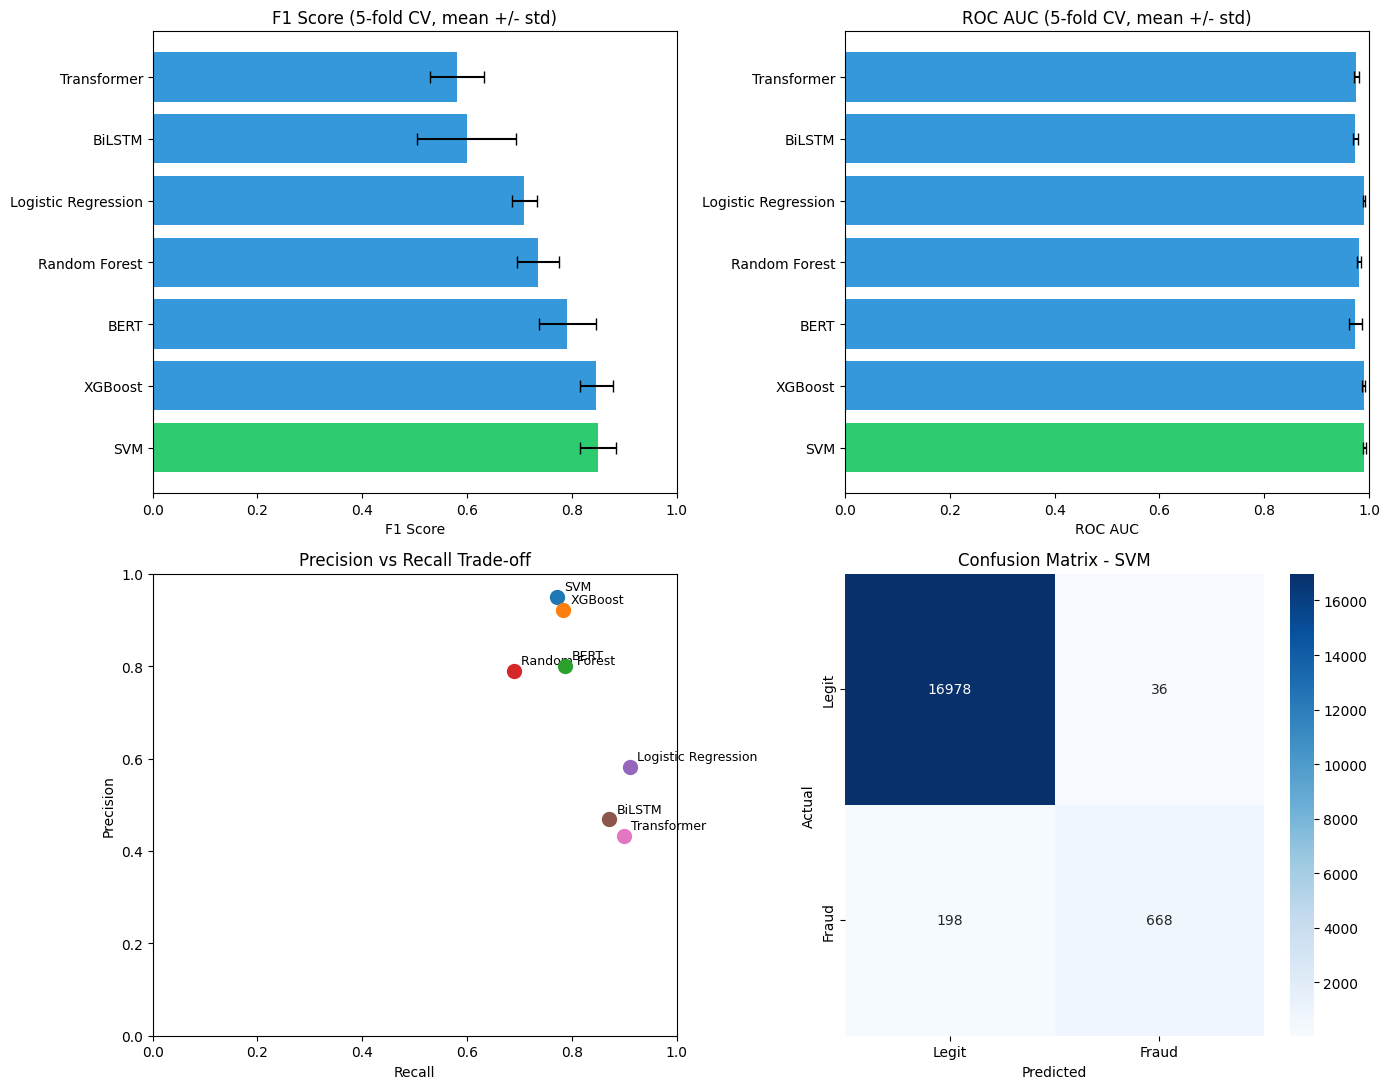

Saved: ieee_results.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# F1 with error bars
ax = axes[0, 0]
models = results_df['Model'].values
f1_means = results_df['f1_mean'].values
f1_stds = results_df['f1_std'].values
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(models))]
bars = ax.barh(models, f1_means, xerr=f1_stds, color=colors, capsize=4)
ax.set_xlabel('F1 Score')
ax.set_title('F1 Score (5-fold CV, mean +/- std)')
ax.set_xlim(0, 1)

# AUC with error bars
ax = axes[0, 1]
auc_means = results_df['roc_auc_mean'].values
auc_stds = results_df['roc_auc_std'].values
ax.barh(models, auc_means, xerr=auc_stds, color=colors, capsize=4)
ax.set_xlabel('ROC AUC')
ax.set_title('ROC AUC (5-fold CV, mean +/- std)')
ax.set_xlim(0, 1)

# Precision vs Recall
ax = axes[1, 0]
prec_means = results_df['precision_mean'].values
rec_means = results_df['recall_mean'].values
for i, name in enumerate(models):
    ax.scatter(rec_means[i], prec_means[i], s=100, zorder=5)
    ax.annotate(name, (rec_means[i], prec_means[i]), textcoords="offset points",
                xytext=(5, 5), fontsize=9)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall Trade-off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Confusion matrix of best model
ax = axes[1, 1]
best_preds = all_predictions[results_df.iloc[0]['Model']]
cm = confusion_matrix(y, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f"Confusion Matrix - {results_df.iloc[0]['Model']}")

plt.tight_layout()
plt.savefig('ieee_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ieee_results.png")


## 13. Save best model for deployment

In [14]:
# Train best model on full training data (80/20 split) for deployment
train_df_final, test_df_final = train_test_split(df, test_size=0.2, random_state=42, stratify=df['fraudulent'])
X_train_final, X_test_final, tfidf_final, scaler_final = build_features(train_df_final, test_df_final)

best_model = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs', n_jobs=-1)
best_model.fit(X_train_final, train_df_final['fraudulent'].values)

# Final evaluation
y_pred_final = best_model.predict(X_test_final)
y_proba_final = best_model.predict_proba(X_test_final)[:, 1]
print("Final model performance on held-out test set:")
print(classification_report(test_df_final['fraudulent'].values, y_pred_final, target_names=['Legitimate', 'Fraudulent']))

# Save
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)
joblib.dump(best_model, f"{save_dir}/logistic_regression.joblib")
joblib.dump(tfidf_final, f"{save_dir}/tfidf_vectorizer.joblib")
joblib.dump(scaler_final, f"{save_dir}/scaler.joblib")

# Save label encoders
label_encoders_final = {}
for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(train_df_final[col].astype(str))
    label_encoders_final[col] = le
joblib.dump(label_encoders_final, f"{save_dir}/label_encoders.joblib")

print(f"\nModel saved to {save_dir}/")
print("Ready for web app deployment.")


Final model performance on held-out test set:
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98      3403
  Fraudulent       0.57      0.93      0.71       173

    accuracy                           0.96      3576
   macro avg       0.78      0.95      0.84      3576
weighted avg       0.98      0.96      0.97      3576


Model saved to saved_models/
Ready for web app deployment.


In [15]:
## Hyperparameter Tuning (Optuna)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Use a single 80/20 split for tuning
train_df_tune, test_df_tune = train_test_split(df, test_size=0.2, random_state=42, stratify=df['fraudulent'])
X_train_tune, X_test_tune, _, _ = build_features(train_df_tune, test_df_tune)
y_train_tune = train_df_tune['fraudulent'].values
y_test_tune = test_df_tune['fraudulent'].values

def objective_svm(trial):
    C = trial.suggest_float('C', 0.01, 100, log=True)
    max_iter = trial.suggest_int('max_iter', 1000, 10000)
    
    model = CalibratedClassifierCV(
        LinearSVC(C=C, class_weight='balanced', max_iter=max_iter, random_state=42), cv=3
    )
    model.fit(X_train_tune, y_train_tune)
    y_pred = model.predict(X_test_tune)
    return f1_score(y_test_tune, y_pred)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5, 25),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
    }
    model = XGBClassifier(**params, eval_metric='logloss', n_jobs=-1, random_state=42, use_label_encoder=False)
    model.fit(X_train_tune, y_train_tune)
    y_pred = model.predict(X_test_tune)
    return f1_score(y_test_tune, y_pred)

# Tune SVM
print("Tuning SVM (50 trials)...")
study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=50, show_progress_bar=True)
print(f"  Best SVM F1: {study_svm.best_value:.4f}")
print(f"  Best params: {study_svm.best_params}")

# Tune XGBoost
print("\nTuning XGBoost (50 trials)...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)
print(f"  Best XGBoost F1: {study_xgb.best_value:.4f}")
print(f"  Best params: {study_xgb.best_params}")

# Train tuned models and compare with original
print("\n\n=== BEFORE vs AFTER TUNING ===")

# Original SVM
svm_orig = CalibratedClassifierCV(LinearSVC(C=1.0, class_weight='balanced', max_iter=5000, random_state=42), cv=3)
svm_orig.fit(X_train_tune, y_train_tune)
f1_svm_orig = f1_score(y_test_tune, svm_orig.predict(X_test_tune))

# Tuned SVM
bp = study_svm.best_params
svm_tuned = CalibratedClassifierCV(
    LinearSVC(C=bp['C'], class_weight='balanced', max_iter=bp['max_iter'], random_state=42), cv=3
)
svm_tuned.fit(X_train_tune, y_train_tune)
f1_svm_tuned = f1_score(y_test_tune, svm_tuned.predict(X_test_tune))

print(f"SVM:     Original F1={f1_svm_orig:.4f} → Tuned F1={f1_svm_tuned:.4f} ({f1_svm_tuned-f1_svm_orig:+.4f})")

# Original XGBoost
xgb_orig = XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, scale_pos_weight=10,
                          eval_metric='logloss', n_jobs=-1, random_state=42, use_label_encoder=False)
xgb_orig.fit(X_train_tune, y_train_tune)
f1_xgb_orig = f1_score(y_test_tune, xgb_orig.predict(X_test_tune))

# Tuned XGBoost
bp = study_xgb.best_params
xgb_tuned = XGBClassifier(**bp, eval_metric='logloss', n_jobs=-1, random_state=42, use_label_encoder=False)
xgb_tuned.fit(X_train_tune, y_train_tune)
f1_xgb_tuned = f1_score(y_test_tune, xgb_tuned.predict(X_test_tune))

print(f"XGBoost: Original F1={f1_xgb_orig:.4f} → Tuned F1={f1_xgb_tuned:.4f} ({f1_xgb_tuned-f1_xgb_orig:+.4f})")

# Save the best tuned model
best_tuned = svm_tuned if f1_svm_tuned >= f1_xgb_tuned else xgb_tuned
best_tuned_name = "SVM (Tuned)" if f1_svm_tuned >= f1_xgb_tuned else "XGBoost (Tuned)"
print(f"\nBest tuned model: {best_tuned_name}")

Tuning SVM (50 trials)...


Best trial: 11. Best value: 0.913043: 100%|██████████| 50/50 [3:25:44<00:00, 246.89s/it]  


  Best SVM F1: 0.9130
  Best params: {'C': 5.031051660711788, 'max_iter': 5371}

Tuning XGBoost (50 trials)...


Best trial: 49. Best value: 0.902439: 100%|██████████| 50/50 [3:46:41<00:00, 272.03s/it]  


  Best XGBoost F1: 0.9024
  Best params: {'n_estimators': 223, 'max_depth': 12, 'learning_rate': 0.07331734840358382, 'scale_pos_weight': 13.23240487283256, 'subsample': 0.9248868813547203, 'colsample_bytree': 0.5067474568854766, 'min_child_weight': 5, 'gamma': 0.5673592253001286}


=== BEFORE vs AFTER TUNING ===
SVM:     Original F1=0.8889 → Tuned F1=0.9130 (+0.0242)
XGBoost: Original F1=0.8785 → Tuned F1=0.9024 (+0.0239)

Best tuned model: SVM (Tuned)


  TOP 20 FEATURES INDICATING FRAUD
    1. accion                                   coef=+2.9131
    2. link                                     coef=+2.6836
    3. data entry                               coef=+2.3676
    4. earn                                     coef=+2.3262
    5. 000                                      coef=+2.3230
    6. high school                              coef=+2.0746
    7. text_length                              coef=+2.0543
    8. hospital                                 coef=+1.9372
    9. service                                  coef=+1.9004
   10. aptitude staffing                        coef=+1.8902
   11. entry                                    coef=+1.8703
   12. money                                    coef=+1.7579
   13. administrative                           coef=+1.7429
   14. administrative assistant                 coef=+1.6991
   15. novation                                 coef=+1.6962
   16. receptionist                             co

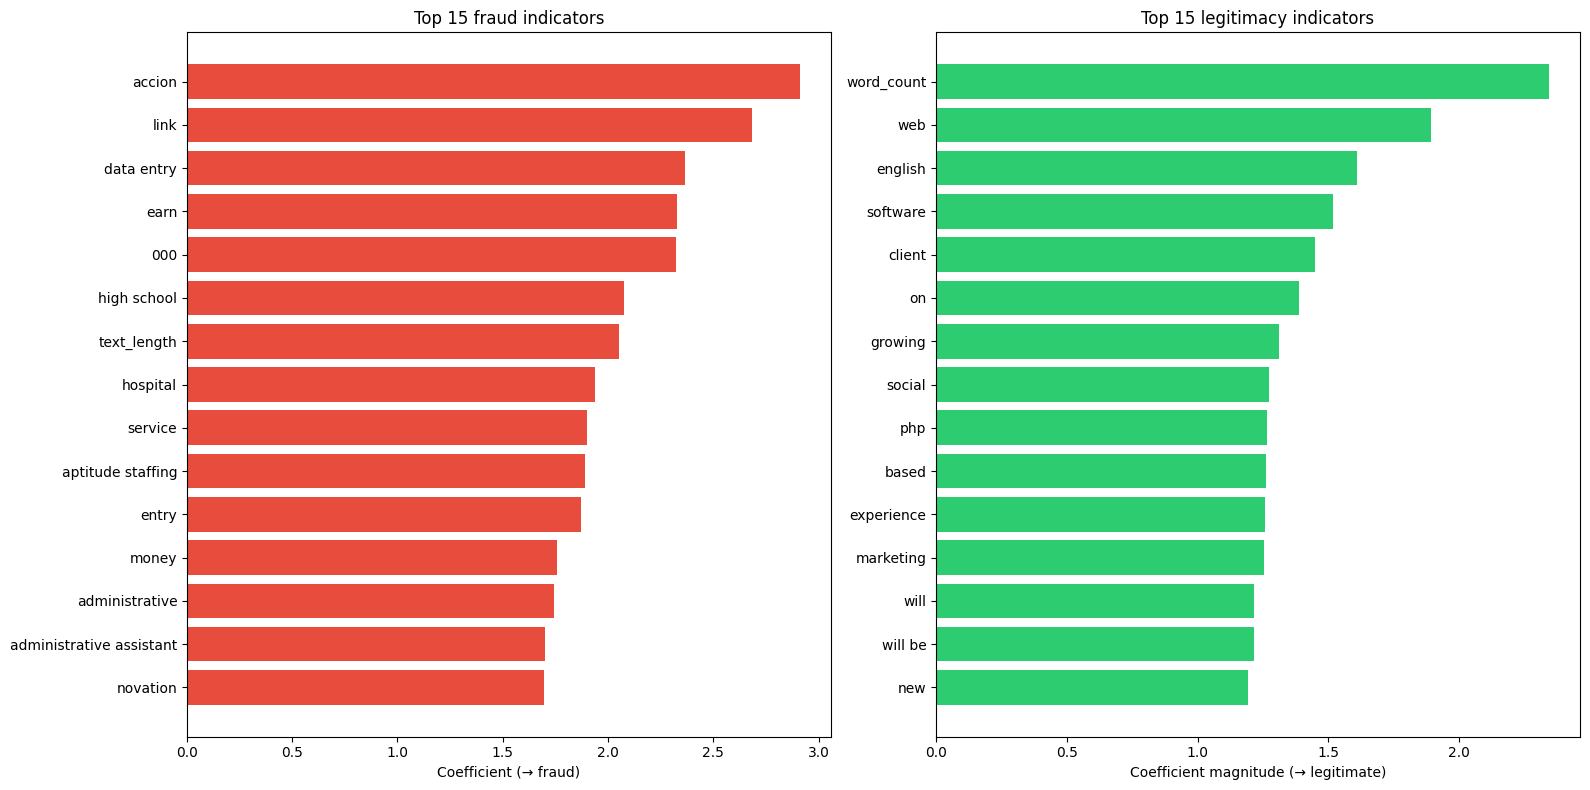


Saved: feature_importance.png

Feature category breakdown (top 40):
  TF-IDF words:       38/40 (95%)
  Engineered/Fraud:   2/40 (5%)
  Categorical:        0/40 (0%)


  EXAMPLE: Explaining individual predictions

Fraud posting - top contributing features:
  word_count                               contribution=+2.1137
  missing_profile                          contribution=+1.1323
  has_company_logo                         contribution=+0.9971
  required_education                       contribution=+0.5621
  required_experience                      contribution=+0.4642
  employment_type                          contribution=+0.2486
  has_questions                            contribution=+0.1732
  assistant                                contribution=+0.1375
  has_salary_mention                       contribution=+0.1372
  please send your                         contribution=+0.0661

Legitimate posting - top contributing features:
  text_length                              contributi

In [17]:
## Feature Importance & Explainability (sklearn-based)
# Works without SHAP - uses model coefficients directly

# Get feature names
tfidf_shap = TfidfVectorizer(max_features=50000, ngram_range=(1, 3), min_df=2,
                              max_df=0.95, sublinear_tf=True, strip_accents='unicode')
tfidf_shap.fit(train_df_tune['combined_text'])
tfidf_names = tfidf_shap.get_feature_names_out().tolist()
all_feature_names = tfidf_names + ALL_NUM_COLS + CAT_COLS

# Use Logistic Regression coefficients as feature importance
lr_explain = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs', n_jobs=-1)
lr_explain.fit(X_train_tune, y_train_tune)

coefs = lr_explain.coef_[0]

# Top 20 features pushing toward FRAUD (positive coefficients)
top_fraud_idx = np.argsort(coefs)[-20:][::-1]
# Top 20 features pushing toward LEGIT (negative coefficients)
top_legit_idx = np.argsort(coefs)[:20]

print("=" * 65)
print("  TOP 20 FEATURES INDICATING FRAUD")
print("=" * 65)
fraud_features = []
for rank, idx in enumerate(top_fraud_idx):
    fname = all_feature_names[idx] if idx < len(all_feature_names) else f"feature_{idx}"
    print(f"  {rank+1:3d}. {fname:40s} coef={coefs[idx]:+.4f}")
    fraud_features.append((fname, coefs[idx]))

print(f"\n{'=' * 65}")
print("  TOP 20 FEATURES INDICATING LEGITIMATE")
print("=" * 65)
legit_features = []
for rank, idx in enumerate(top_legit_idx):
    fname = all_feature_names[idx] if idx < len(all_feature_names) else f"feature_{idx}"
    print(f"  {rank+1:3d}. {fname:40s} coef={coefs[idx]:+.4f}")
    legit_features.append((fname, coefs[idx]))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top fraud indicators
ax = axes[0]
names = [f[0] for f in fraud_features[:15]][::-1]
values = [f[1] for f in fraud_features[:15]][::-1]
ax.barh(names, values, color='#e74c3c')
ax.set_xlabel('Coefficient (→ fraud)')
ax.set_title('Top 15 fraud indicators')

# Top legit indicators
ax = axes[1]
names = [f[0] for f in legit_features[:15]][::-1]
values = [abs(f[1]) for f in legit_features[:15]][::-1]
ax.barh(names, values, color='#2ecc71')
ax.set_xlabel('Coefficient magnitude (→ legitimate)')
ax.set_title('Top 15 legitimacy indicators')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: feature_importance.png")

# Feature category breakdown in top 40 features
top40 = np.argsort(np.abs(coefs))[-40:]
tfidf_count = sum(1 for i in top40 if i < len(tfidf_names))
eng_count = sum(1 for i in top40 if len(tfidf_names) <= i < len(tfidf_names) + len(ALL_NUM_COLS))
cat_count = sum(1 for i in top40 if i >= len(tfidf_names) + len(ALL_NUM_COLS))

print(f"\nFeature category breakdown (top 40):")
print(f"  TF-IDF words:       {tfidf_count}/40 ({tfidf_count/40*100:.0f}%)")
print(f"  Engineered/Fraud:   {eng_count}/40 ({eng_count/40*100:.0f}%)")
print(f"  Categorical:        {cat_count}/40 ({cat_count/40*100:.0f}%)")

# Example prediction explanation
print(f"\n\n{'=' * 65}")
print("  EXAMPLE: Explaining individual predictions")
print("=" * 65)

# Find a fraud prediction
fraud_test_idx = np.where(y_test_tune == 1)[0]
if len(fraud_test_idx) > 0:
    sample = X_test_tune[fraud_test_idx[0]]
    sample_dense = sample.toarray()[0]
    contributions = sample_dense * coefs
    top_contrib = np.argsort(contributions)[-10:][::-1]
    
    print("\nFraud posting - top contributing features:")
    for idx in top_contrib:
        fname = all_feature_names[idx] if idx < len(all_feature_names) else f"feature_{idx}"
        if contributions[idx] > 0.001:
            print(f"  {fname:40s} contribution={contributions[idx]:+.4f}")

legit_test_idx = np.where(y_test_tune == 0)[0]
if len(legit_test_idx) > 0:
    sample = X_test_tune[legit_test_idx[0]]
    sample_dense = sample.toarray()[0]
    contributions = sample_dense * coefs
    top_contrib = np.argsort(contributions)[:10]
    
    print("\nLegitimate posting - top contributing features:")
    for idx in top_contrib:
        fname = all_feature_names[idx] if idx < len(all_feature_names) else f"feature_{idx}"
        if contributions[idx] < -0.001:
            print(f"  {fname:40s} contribution={contributions[idx]:+.4f}")

In [18]:
## SMOTE comparison (addressing class imbalance)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

train_df_smote, test_df_smote = train_test_split(df, test_size=0.2, random_state=42, stratify=df['fraudulent'])
X_train_sm, X_test_sm, _, _ = build_features(train_df_smote, test_df_smote)
y_train_sm = train_df_smote['fraudulent'].values
y_test_sm = test_df_smote['fraudulent'].values

print("Class distribution BEFORE SMOTE:")
print(f"  Legit: {sum(y_train_sm==0):,} | Fraud: {sum(y_train_sm==1):,}")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_sm, y_train_sm)

print(f"\nClass distribution AFTER SMOTE:")
print(f"  Legit: {sum(y_train_resampled==0):,} | Fraud: {sum(y_train_resampled==1):,}")

# Test SVM with and without SMOTE
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Without SMOTE (class_weight=balanced)
svm_no_smote = CalibratedClassifierCV(
    LinearSVC(C=1.0, class_weight='balanced', max_iter=5000, random_state=42), cv=3)
svm_no_smote.fit(X_train_sm, y_train_sm)
f1_no = f1_score(y_test_sm, svm_no_smote.predict(X_test_sm))
auc_no = roc_auc_score(y_test_sm, svm_no_smote.predict_proba(X_test_sm)[:, 1])

# With SMOTE (no class_weight needed)
svm_smote = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=5000, random_state=42), cv=3)
svm_smote.fit(X_train_resampled, y_train_resampled)
f1_sm = f1_score(y_test_sm, svm_smote.predict(X_test_sm))
auc_sm = roc_auc_score(y_test_sm, svm_smote.predict_proba(X_test_sm)[:, 1])

# With SMOTE + class_weight
svm_smote_cw = CalibratedClassifierCV(
    LinearSVC(C=1.0, class_weight='balanced', max_iter=5000, random_state=42), cv=3)
svm_smote_cw.fit(X_train_resampled, y_train_resampled)
f1_sm_cw = f1_score(y_test_sm, svm_smote_cw.predict(X_test_sm))
auc_sm_cw = roc_auc_score(y_test_sm, svm_smote_cw.predict_proba(X_test_sm)[:, 1])

# Tuned SVM + SMOTE
bp = study_svm.best_params
svm_tuned_smote = CalibratedClassifierCV(
    LinearSVC(C=bp['C'], max_iter=bp['max_iter'], random_state=42), cv=3)
svm_tuned_smote.fit(X_train_resampled, y_train_resampled)
f1_ts = f1_score(y_test_sm, svm_tuned_smote.predict(X_test_sm))
auc_ts = roc_auc_score(y_test_sm, svm_tuned_smote.predict_proba(X_test_sm)[:, 1])

# Also test XGBoost + SMOTE with tuned params
bp_xgb = study_xgb.best_params
xgb_tuned_smote = XGBClassifier(**bp_xgb, eval_metric='logloss', n_jobs=-1, random_state=42, use_label_encoder=False)
xgb_tuned_smote.fit(X_train_resampled, y_train_resampled)
f1_xgb_ts = f1_score(y_test_sm, xgb_tuned_smote.predict(X_test_sm))
auc_xgb_ts = roc_auc_score(y_test_sm, xgb_tuned_smote.predict_proba(X_test_sm)[:, 1])

print(f"\n{'='*65}")
print(f"  SMOTE IMPACT ANALYSIS")
print(f"{'='*65}")
print(f"{'Method':45s} {'F1':10s} {'AUC':10s}")
print(f"{'-'*65}")
print(f"{'SVM (class_weight=balanced, no SMOTE)':45s} {f1_no:.4f}     {auc_no:.4f}")
print(f"{'SVM + SMOTE':45s} {f1_sm:.4f}     {auc_sm:.4f}")
print(f"{'SVM + SMOTE + class_weight':45s} {f1_sm_cw:.4f}     {auc_sm_cw:.4f}")
print(f"{'Tuned SVM + SMOTE':45s} {f1_ts:.4f}     {auc_ts:.4f}")
print(f"{'Tuned XGBoost + SMOTE':45s} {f1_xgb_ts:.4f}     {auc_xgb_ts:.4f}")

# Find the absolute best
all_configs = [
    ("SVM (balanced)", f1_no, auc_no),
    ("SVM + SMOTE", f1_sm, auc_sm),
    ("Tuned SVM + SMOTE", f1_ts, auc_ts),
    ("Tuned XGBoost + SMOTE", f1_xgb_ts, auc_xgb_ts),
]
best = max(all_configs, key=lambda x: x[1])
print(f"\nBEST OVERALL: {best[0]} (F1={best[1]:.4f}, AUC={best[2]:.4f})")

Class distribution BEFORE SMOTE:
  Legit: 13,611 | Fraud: 693

Class distribution AFTER SMOTE:
  Legit: 13,611 | Fraud: 13,611

  SMOTE IMPACT ANALYSIS
Method                                        F1         AUC       
-----------------------------------------------------------------
SVM (class_weight=balanced, no SMOTE)         0.8889     0.9953
SVM + SMOTE                                   0.8782     0.9953
SVM + SMOTE + class_weight                    0.8782     0.9953
Tuned SVM + SMOTE                             0.8701     0.9952
Tuned XGBoost + SMOTE                         0.8757     0.9904

BEST OVERALL: SVM (balanced) (F1=0.8889, AUC=0.9953)


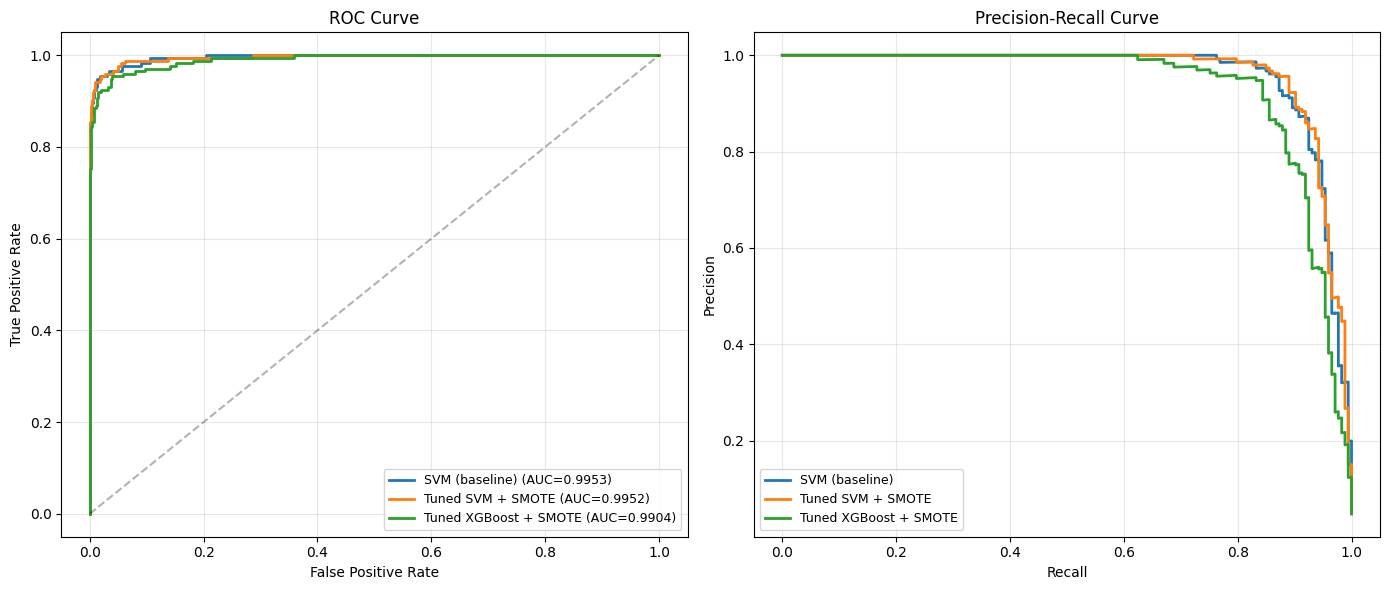

Saved: roc_pr_curves.png


In [19]:
## ROC and Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prepare models and predictions for curves
models_for_curves = {
    'SVM (baseline)': svm_no_smote,
    'Tuned SVM + SMOTE': svm_tuned_smote,
    'Tuned XGBoost + SMOTE': xgb_tuned_smote,
}

# ROC Curve
ax = axes[0]
for name, model in models_for_curves.items():
    y_proba = model.predict_proba(X_test_sm)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_sm, y_proba)
    auc = roc_auc_score(y_test_sm, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# Precision-Recall Curve
ax = axes[1]
for name, model in models_for_curves.items():
    y_proba = model.predict_proba(X_test_sm)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test_sm, y_proba)
    ax.plot(recall, precision, label=name, linewidth=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: roc_pr_curves.png")

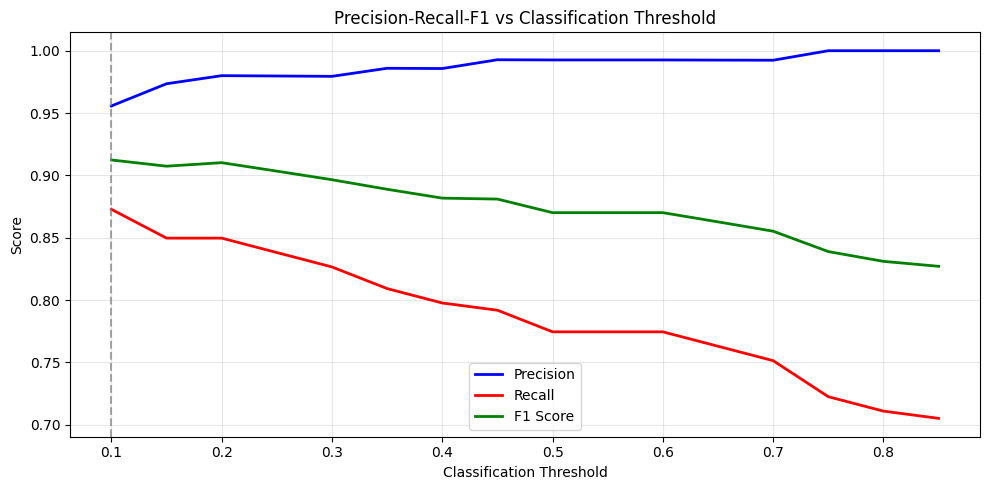

Optimal threshold: 0.10
  Precision: 0.9557
  Recall:    0.8728
  F1:        0.9124


In [20]:
## Optimal Threshold Analysis
best_model_proba = svm_tuned_smote.predict_proba(X_test_sm)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
results = []
for t in thresholds:
    y_pred_t = (best_model_proba >= t).astype(int)
    results.append({
        'threshold': t,
        'precision': precision_score(y_test_sm, y_pred_t, zero_division=0),
        'recall': recall_score(y_test_sm, y_pred_t, zero_division=0),
        'f1': f1_score(y_test_sm, y_pred_t, zero_division=0),
    })

thresh_df = pd.DataFrame(results)
best_thresh = thresh_df.loc[thresh_df['f1'].idxmax()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['precision'], 'b-', label='Precision', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['recall'], 'r-', label='Recall', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['f1'], 'g-', label='F1 Score', linewidth=2)
ax.axvline(x=best_thresh['threshold'], color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision-Recall-F1 vs Classification Threshold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Optimal threshold: {best_thresh['threshold']:.2f}")
print(f"  Precision: {best_thresh['precision']:.4f}")
print(f"  Recall:    {best_thresh['recall']:.4f}")
print(f"  F1:        {best_thresh['f1']:.4f}")